In [4]:
import sqlite3
import pandas as pd

conn=sqlite3.connect('../data/analytics.db')

In [ ]:
# Total number of unique customers
pd.read_sql("Select count(distinct(customer_id)) as total_customers from transactions",conn)

,total_customers
0,2000


In [ ]:
# Basket Size
query="""select avg(item_count) as avg_items_per_transaction from 
(select transaction_id,count(*) as item_count from transaction_items group by transaction_id)"""

pd.read_sql(query,conn)

,avg_items_per_transaction
0,3.41245


In [15]:
#Avg spend per customer
query="""
select t.customer_id,sum(total_amount) as total_spend from transactions t
group by t.customer_id
order by total_spend desc
"""
pd.read_sql(query,conn)

,customer_id,total_spend
0,162,1612.09
1,1856,1435.93
2,865,1386.18
3,1341,1376.13
4,459,1298.29
...,...,...
1995,555,100.72
1996,230,87.77
1997,1916,64.74
1998,300,35.55


In [14]:
# Frequency of purchases per customer
query="""
select t.customer_id,count(distinct(t.transaction_id)) as purchase_frequency from transactions t
group by t.customer_id
order by purchase_frequency desc"""
pd.read_sql(query,conn)

,customer_id,purchase_frequency
0,162,25
1,459,23
2,1341,21
3,1077,21
4,865,21
...,...,...
1995,1916,2
1996,300,2
1997,151,2
1998,76,2


In [17]:
# Recency, Frequency, Monetary (RFM) Analysis
query="""
select t.customer_id,
       max(t.ts) as last_purchase_date,
       count(distinct(t.transaction_id)) as frequency,
       sum(t.total_amount) as monetary
from transactions t
group by t.customer_id
order by monetary desc
"""
rfm=pd.read_sql(query,conn)
print(rfm)
print(rfm.head())

      customer_id          last_purchase_date  frequency  monetary
0             162  2025-09-18T01:40:31.699573         25   1612.09
1            1856  2025-08-13T07:32:31.699573         19   1435.93
2             865  2025-09-05T19:29:31.699573         21   1386.18
3            1341  2025-09-01T11:04:31.699573         21   1376.13
4             459  2025-09-21T06:12:31.699573         23   1298.29
...           ...                         ...        ...       ...
1995          555  2025-09-03T19:26:31.699573          3    100.72
1996          230  2025-05-06T16:46:31.699573          3     87.77
1997         1916  2025-03-27T19:41:31.699573          2     64.74
1998          300  2025-06-13T20:20:31.699573          2     35.55
1999          133  2025-02-26T20:20:31.699573          1     12.00

[2000 rows x 4 columns]
   customer_id          last_purchase_date  frequency  monetary
0          162  2025-09-18T01:40:31.699573         25   1612.09
1         1856  2025-08-13T07:32:31.699573 

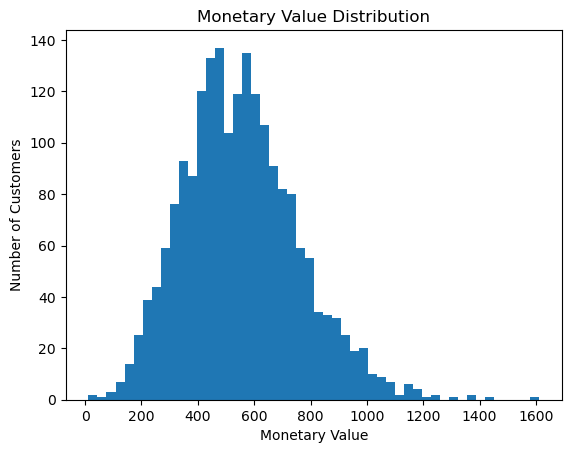

In [ ]:
# Monetary Value Distribution Visualization
import matplotlib.pyplot as plt
plt.hist(rfm['monetary'], bins=50)
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Number of Customers')
plt.show()

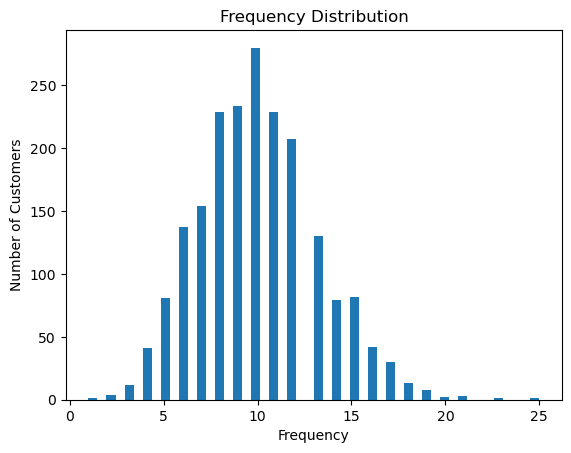

In [ ]:
# Frequency Distribution Visualization
import matplotlib.pyplot as plt
plt.hist(rfm['frequency'], bins=50)
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')
plt.show()